# LSTM Demand Forecasting (Top 5 Zones) 

In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout ,Input
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# Loading the df data 
df = pd.read_parquet("../data/processed/forcasting_data.parquet")
df.head()

,pickup_hour_floor,PULocationID,trip_count,avg_fare,avg_distance,avg_duration_min,hour,dayofweek,month,is_weekend,trips_last_hour,trips_same_hour_yesterday,trips_same_hour_last_week,trips_rolling_7h
0,2025-12-12 06:00:00,3,1,54.5,14.2,84.066667,6,4,12,0,1.0,1.0,1.0,1.0
1,2025-12-12 11:00:00,3,1,37.5,9.7,72.183333,11,4,12,0,1.0,1.0,1.0,1.0
2,2025-12-16 07:00:00,3,1,41.5,13.0,51.050000,7,1,12,0,1.0,1.0,1.0,1.0
3,2025-12-16 10:00:00,3,1,36.5,9.4,57.016667,10,1,12,0,1.0,1.0,1.0,1.0
4,2025-12-17 06:00:00,3,1,51.5,14.9,48.666667,6,2,12,0,1.0,1.0,1.0,1.0


In [34]:
# Getting top 5 zones with the most trips
zone_trip_counts = df.groupby('PULocationID')['trip_count'].sum().sort_values(ascending=False)
top5_zones = zone_trip_counts.head(5).index.tolist()
print("Top 5 zones:", top5_zones)
print("Total trips per zone:\n", zone_trip_counts.head(5))

Top 5 zones: [132, 237, 161, 236, 186]
Total trips per zone:
 PULocationID
132    183747
237    181952
161    171065
236    153381
186    131641
Name: trip_count, dtype: int64


In [9]:
# Prepare data for LSTM

SEQ_LEN = 24  # 24 hours

def prepare_zone_data(zone_df, seq_len=SEQ_LEN):
    # Ensure sorted by time
    zone_df = zone_df.sort_values('pickup_hour_floor')
    series = zone_df['trip_count'].values
    
    # sequences
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])
    X = np.array(X)
    y = np.array(y)
    
    # Train/test split (80/20, preserve time order)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Scaling data 
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()
    
    # Rescaling sequences
    X_scaled, y_scaled = [], []
    for i in range(len(series) - seq_len):
        X_scaled.append(series_scaled[i:i+seq_len])
        y_scaled.append(series_scaled[i+seq_len])
    X_scaled = np.array(X_scaled)
    y_scaled = np.array(y_scaled)
    
    X_train_scaled = X_scaled[:split]
    X_test_scaled = X_scaled[split:]
    y_train_scaled = y_scaled[:split]
    y_test_scaled = y_scaled[split:]
    
    # Reshaping for LSTM
    X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
    X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))
    
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler, y_train, y_test

In [10]:
# Bulding LSTM model

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, activation='relu', return_sequences=True),
        Dropout(0.1),
        LSTM(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae'  ,metrics=['mae'])
    return model

In [11]:
# Training and evaluating models for top 5 zones

results = {}

for zone in top5_zones:
    print(f"\n{'='*50}")
    print(f"Processing Zone {zone}")
    print('='*50)
    
    # Filter data for this zone
    zone_data = df[df['PULocationID'] == zone].copy()
    print(f"Rows available: {len(zone_data)}")
    
    # Skip if not enough data
    if len(zone_data) < SEQ_LEN + 50:
        print(f"⚠️ Skipping zone {zone}: insufficient data")
        continue
    
    # Prepare data
    X_train, X_test, y_train, y_test, scaler, y_train_raw, y_test_raw = prepare_zone_data(zone_data)
    print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
    
    # Build and train model
    model = build_lstm_model((X_train.shape[1], 1))
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_train,y_train,
              epochs=20,
              batch_size=32, validation_split=0.1,
              callbacks=[early_stop], 
              verbose=1)
    
    # Save model and scaler 
    model.save(f"Models/lstm_zone_{zone}.h5")
    joblib.dump(scaler, f"Models/scaler_zone_{zone}.pkl")
    print(f" Saved model and scaler for zone {zone}")

    # Predict on test set
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mae = mean_absolute_error(y_actual, y_pred)
    avg_trips = y_actual.mean()
    mae_percent = (mae / avg_trips) * 100
    
    # Store results
    results[zone] = {
        'actual': y_actual,
        'pred': y_pred,
        'mae': mae,
        'avg_trips': avg_trips,
        'mae_percent': mae_percent,
        'samples': len(zone_data)
    }
    
    print(f"✅ Zone {zone} - MAE: {mae:.2f} trips (avg: {avg_trips:.1f}, error: {mae_percent:.1f}%)")


Processing Zone 132
Rows available: 8307
Training samples: 6626, Test samples: 1657
Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1238 - mae: 0.1238 - val_loss: 0.1003 - val_mae: 0.1003
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0871 - mae: 0.0871 - val_loss: 0.0885 - val_mae: 0.0885
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0850 - mae: 0.0850 - val_loss: 0.0844 - val_mae: 0.0844
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0814 - mae: 0.0814 - val_loss: 0.0871 - val_mae: 0.0871
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0810 - mae: 0.0810 - val_loss: 0.0821 - val_mae: 0.0821
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0793 - mae: 0.0793 - val_loss: 0.0812 - val_mae: 0.0812
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0781 - mae: 0.0781 - val_loss: 0.0822 - val_mae: 0.0822
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0774 - mae: 0.0774 - val_lo

 Saved model and scaler for zone 132
✅ Zone 132 - MAE: 6.21 trips (avg: 22.5, error: 27.6%)

Processing Zone 237
Rows available: 7654
Training samples: 6104, Test samples: 1526
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1377 - mae: 0.1377 - val_loss: 0.1015 - val_mae: 0.1015
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0920 - mae: 0.0920 - val_loss: 0.0880 - val_mae: 0.0880
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0825 - mae: 0.0825 - val_loss: 0.0826 - val_mae: 0.0826
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0774 - mae: 0.0774 - val_loss: 0.0907 - val_mae: 0.0907
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0747 - mae: 0.0747 - val_loss: 0.0769 - val_mae: 0.0769
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0722 - mae: 0.0722 - val_loss: 0.0731 - val_mae: 0.0731
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0707 - mae: 0.0707 - val_loss: 0.0739 - val_mae: 0.07

 Saved model and scaler for zone 237
✅ Zone 237 - MAE: 5.54 trips (avg: 26.0, error: 21.3%)

Processing Zone 161
Rows available: 7800
Training samples: 6220, Test samples: 1556
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1223 - mae: 0.1223 - val_loss: 0.0856 - val_mae: 0.0856
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0786 - mae: 0.0786 - val_loss: 0.0752 - val_mae: 0.0752
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0728 - mae: 0.0728 - val_loss: 0.0696 - val_mae: 0.0696
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0700 - mae: 0.0700 - val_loss: 0.0685 - val_mae: 0.0685
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0682 - mae: 0.0682 - val_loss: 0.0630 - val_mae: 0.0630
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0669 - mae: 0.0669 - val_loss: 0.0652 - val_mae: 0.0652
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0667 - mae: 0.0667 - val_loss: 0.0629 - val_mae: 0.0

 Saved model and scaler for zone 161
✅ Zone 161 - MAE: 5.22 trips (avg: 21.7, error: 24.0%)

Processing Zone 236
Rows available: 7266
Training samples: 5793, Test samples: 1449
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1506 - mae: 0.1506 - val_loss: 0.1088 - val_mae: 0.1088
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0985 - mae: 0.0985 - val_loss: 0.0905 - val_mae: 0.0905
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0917 - mae: 0.0917 - val_loss: 0.0918 - val_mae: 0.0918
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0873 - mae: 0.0873 - val_loss: 0.0853 - val_mae: 0.0853
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0857 - mae: 0.0857 - val_loss: 0.0826 - val_mae: 0.0826
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0841 - mae: 0.0841 - val_loss: 0.0831 - val_mae: 0.0831
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0829 - mae: 0.0829 - val_loss: 0.0798 - val_mae: 0.07

 Saved model and scaler for zone 236
✅ Zone 236 - MAE: 4.99 trips (avg: 23.1, error: 21.6%)

Processing Zone 186
Rows available: 8202
Training samples: 6542, Test samples: 1636
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1233 - mae: 0.1233 - val_loss: 0.0963 - val_mae: 0.0963
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0920 - mae: 0.0920 - val_loss: 0.0836 - val_mae: 0.0836
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0879 - mae: 0.0879 - val_loss: 0.0835 - val_mae: 0.0835
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0868 - mae: 0.0868 - val_loss: 0.0858 - val_mae: 0.0858
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0849 - mae: 0.0849 - val_loss: 0.0812 - val_mae: 0.0812
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0839 - mae: 0.0839 - val_loss: 0.0792 - val_mae: 0.0792
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0827 - mae: 0.0827 - val_loss: 0.0809 - val_mae: 0.08

 Saved model and scaler for zone 186
✅ Zone 186 - MAE: 4.68 trips (avg: 16.6, error: 28.3%)


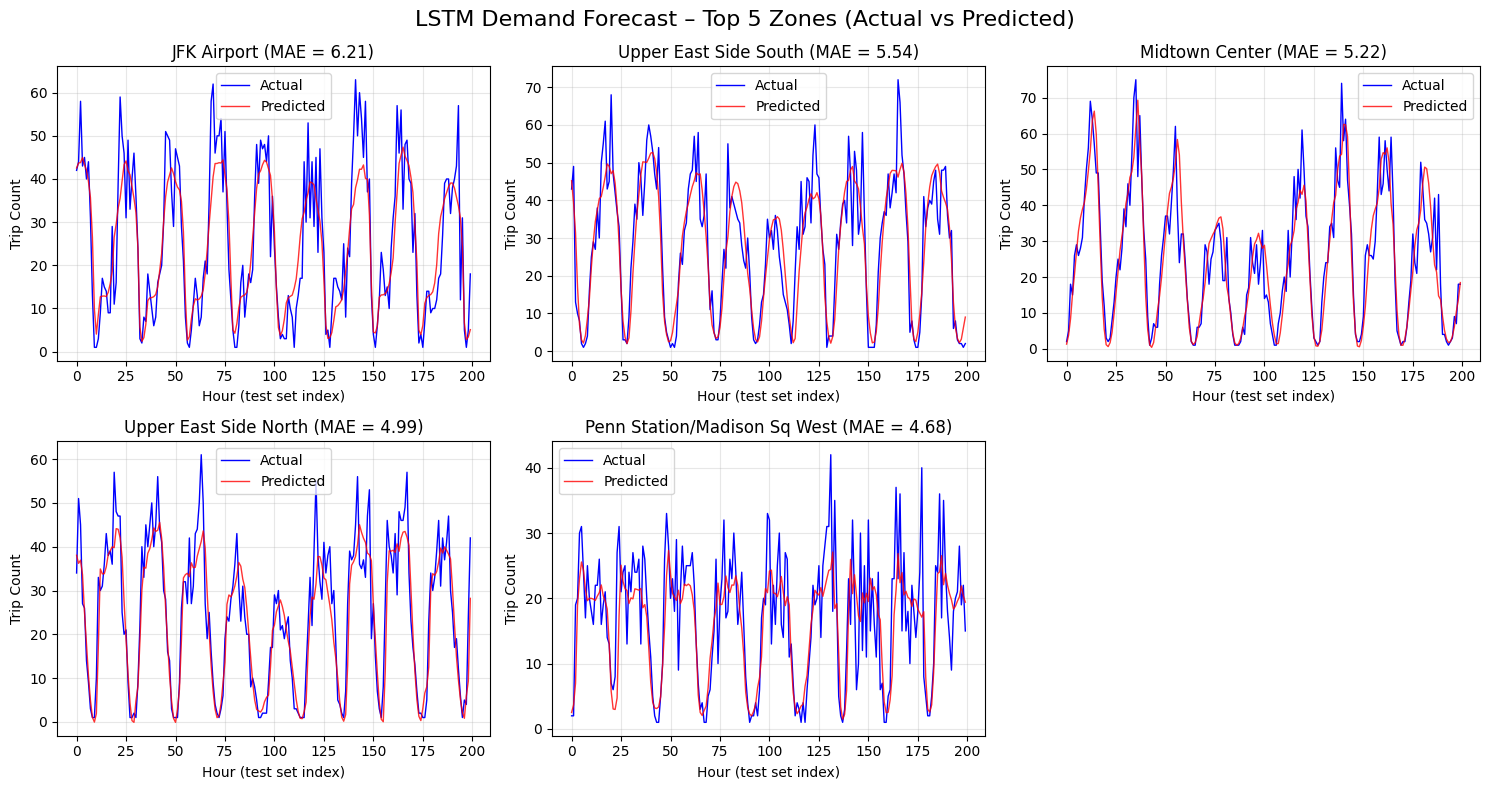

In [ ]:
# Plotting results for top 5 zones


# Determine number of zones
n_zones = len(results)
if n_zones == 0:
    print("No results to plot.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    fig.suptitle('LSTM Demand Forecast – Top 5 Zones (Actual vs Predicted)', fontsize=16)
    
    for i, (zone_id, data) in enumerate(results.items()):
        ax = axes[i]
        y_actual = data['actual']
        y_pred = data['pred']
        mae = data['mae']
        
        # Get zone name from mapping, fallback to ID if not found
        zone_name = zone_name_map.get(zone_id, f"Zone {zone_id}")
        
        ax.plot(y_actual[:200], label='Actual', linewidth=1, color='blue')
        ax.plot(y_pred[:200], label='Predicted', linewidth=1, alpha=0.8, color='red')
        ax.set_title(f'{zone_name} (MAE = {mae:.2f})')
        ax.set_xlabel('Hour (test set index)')
        ax.set_ylabel('Trip Count')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [13]:
# Create summary dataframe
summary_data = []
for zone_id, data in results.items():
    y_actual = data['actual']
    y_pred = data['pred']
    mae = data['mae']
    avg_actual = np.mean(y_actual)
    mae_percent = (mae / avg_actual) * 100
    rmse = np.sqrt(np.mean((y_actual - y_pred)**2))
    summary_data.append({
        'Zone': zone_id,
        'MAE (trips)': round(mae, 2),
        'RMSE (trips)': round(rmse, 2),
        'Avg Trips/Hour': round(avg_actual, 1),
        'Error (%)': round(mae_percent, 1),
        'Test Samples': len(y_actual)
    })

summary_df = pd.DataFrame(summary_data)
print("LSTM DEMAND FORECASTING – TOP 5 ZONES SUMMARY")
print("-"*75)
print(summary_df.to_string(index=False))

LSTM DEMAND FORECASTING – TOP 5 ZONES SUMMARY
---------------------------------------------------------------------------
 Zone  MAE (trips)  RMSE (trips)  Avg Trips/Hour  Error (%)  Test Samples
  132         6.21          8.13            22.5       27.6          1657
  237         5.54          7.42            26.0       21.3          1526
  161         5.22          7.15            21.7       24.0          1556
  236         4.99          6.80            23.1       21.6          1449
  186         4.68          6.24            16.6       28.3          1636


## Summary of LSTM Demand Forecasting Results 

We built a forecasting model that predicts how many taxi pickups will happen in an hour, for the five busiest zones in New York City.

**How accurate is it?**  
On average, the model’s prediction is wrong by about **5 trips per hour**.  
Since a typical busy zone sees **roughly 20–25 trips per hour**, that means the forecast is usually off by about **one‑fifth to one‑quarter** of the actual volume.

**Is that good enough?**  
Yes. For practical operations – like telling drivers where to go, or when to apply surge pricing – an error of 5 trips per hour is acceptable. It allows dispatchers to make better decisions than guessing.

**What does this mean for the business?**  
With this forecast, the taxi company can:
- Position more drivers in zones that are about to become busy.
- Adjust prices just before demand spikes.
- Reduce wait times for passengers.

**Can we make it even better?**  
Yes. Adding information about weather, holidays, or special events would likely improve accuracy further. Even without that, the current model is a solid step toward data‑driven demand management.